## Preparation

src: [Fine-tuning BERT for an unbalanced multi-class classification problem By Antoine Caytan](https://dataroots.io/blog/incident-team-prediction)

code: https://dataroots.ghost.io/content/files/2023/05/incident_description_team_prediction.ipynb

#### Installations

In [ ]:
# ! pip install Faker transformers

#### Imports

In [ ]:
import nltk
import re
import string
import torch
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from tqdm.notebook import tqdm
from faker import Faker
from datetime import datetime, timedelta
from collections import OrderedDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#### Global Variables

In [ ]:
random_state = 42

## Data

#### Generate manual data to meet explainations

In [ ]:
# Define a fake but relevant dataset
data = [
    {"number": "INC001", "company": "Woodard PLC",      "team": "team_aa", "priority": 1, "urgency": 1,
        "opened_at": "2023-04-17", "closed_at": np.nan,       "description": "team_x : Memory usage above threshold 10"},
    {"number": "INC002", "company": "Washington-Rios",  "team": "team_ab", "priority": 2, "urgency": 2,
        "opened_at": "2023-04-17", "closed_at": np.nan,       "description": "job1 has status failed with docker.image_example08"},
    {"number": "INC003", "company": "Carson-Frazier",   "team": "team_ab", "priority": 3, "urgency": 3,
        "opened_at": "2023-04-17", "closed_at": np.nan,       "description": "Dell computer cannot login to web server"},
    {"number": "INC004", "company": "Petty Ltd",        "team": "team_ac", "priority": 2, "urgency": 3, "opened_at": "2023-04-15",
        "closed_at": "2023-04-17", "description": "Ingestion failed because of bad policy : tokenize.employee.name"},
    {"number": "INC005", "company": "Chen-Sanders",     "team": "team_ad", "priority": 3, "urgency": 2,
        "opened_at": "2023-04-15", "closed_at": "2023-04-16", "description": "Email server down : server.jx_A01-B22"},
]

# Initialize the pandas DataFrame with the list of dictionaries
df = pd.DataFrame(data)

#### Set up the automatic data generation

In [ ]:
# Parameters
n_teams = 30  # Specify the number of teams
lambda_val = 50  # Exponential distribution parameter
random.seed(random_state)

# Generate the team names
team_names = []
for i in range(n_teams):
    for j in string.ascii_lowercase:
        for k in string.ascii_lowercase:
            team_names.append("team_{}{}".format(j, k))

# Generate the distribution values
probabilities = np.random.exponential(scale=1/lambda_val, size=n_teams)
# Normalize probabilities to sum up to 1
probabilities /= np.sum(probabilities)

# Create dictionary with team names as keys and probabilities as values
team_distribution = OrderedDict(zip(team_names, probabilities))

In [ ]:
print(len(team_distribution))

30


#### Generate the data

In [ ]:
# Create an instance of Fake
fake = Faker()

# Generate fake data
data = []
for i in range(1000):
    number = "INC" + str(fake.unique.random_number(digits=4, fix_len=True))
    company = fake.company()
    team = fake.random_choices(elements=team_distribution, length=1)[0]
    priority = fake.random_int(min=1, max=3)
    urgency = fake.random_int(min=1, max=3)
    opened_at = fake.date_between(start_date="-30d", end_date="today")
    closed_at = fake.date_between(start_date=opened_at + timedelta(
        days=1), end_date="today") if fake.boolean(chance_of_getting_true=80) else np.nan
    description = fake.sentence(nb_words=5)
    data.append({"number": number, "company": company, "team": team, "priority": priority,
                "urgency": urgency, "opened_at": opened_at, "closed_at": closed_at, "description": description})

# Convert the list of dictionaries to a Pandas DataFrame
more_df = pd.DataFrame(data)

# Concatenate the relevant dataframe with this one
incidents = pd.concat([df, more_df], ignore_index=True)

# Convert the "opened_at" and "closed_at" columns to datetime objects
incidents["opened_at"] = pd.to_datetime(incidents["opened_at"])
incidents["closed_at"] = pd.to_datetime(incidents["closed_at"])

# Sort the DataFrame by "opened_at" column in descending order
incidents = incidents.sort_values("number", ascending=True)

# Reset the index of the DataFrame
incidents = incidents.reset_index(drop=True)

In [ ]:
incidents

,number,company,team,priority,urgency,opened_at,closed_at,description
0,INC001,Woodard PLC,team_aa,1,1,2023-04-17,NaT,team_x : Memory usage above threshold 10
1,INC002,Washington-Rios,team_ab,2,2,2023-04-17,NaT,job1 has status failed with docker.image_examp...
2,INC003,Carson-Frazier,team_ab,3,3,2023-04-17,NaT,Dell computer cannot login to web server
3,INC004,Petty Ltd,team_ac,2,3,2023-04-15,2023-04-17,Ingestion failed because of bad policy : token...
4,INC005,Chen-Sanders,team_ad,3,2,2023-04-15,2023-04-16,Email server down : server.jx_A01-B22
...,...,...,...,...,...,...,...,...
1000,INC9954,"Flores, Anderson and Hutchinson",team_az,1,1,2023-04-13,2023-04-25,Share fall almost.
1001,INC9963,Johnson Ltd,team_ab,1,2,2023-04-15,NaT,Establish outside manager house late.
1002,INC9969,"Brown, Watson and Murphy",team_al,2,3,2023-04-14,2023-05-02,President effort between.
1003,INC9970,"York, Rogers and Wright",team_az,1,2,2023-04-19,NaT,Simple over significant consider always author.


## Preprocess the data

#### Keep the original description

In [ ]:
incidents["original_description"] = incidents["description"].copy()

#### Stopwords

In [ ]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

incidents["description"] = incidents["description"].apply(lambda x: " ".join(
    [word for word in x.split() if word.lower() not in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
incidents["original_description"].head(5)

0             team_x : Memory usage above threshold 10
1    job1 has status failed with docker.image_examp...
2             Dell computer cannot login to web server
3    Ingestion failed because of bad policy : token...
4                Email server down : server.jx_A01-B22
Name: original_description, dtype: object

In [ ]:
incidents["description"].head(5)

0                   team_x : Memory usage threshold 10
1            job1 status failed docker.image_example08
2                Dell computer cannot login web server
3    Ingestion failed bad policy : tokenize.employe...
4                     Email server : server.jx_A01-B22
Name: description, dtype: object

#### Punctuation

In [ ]:
# Define a regex string to match punctuation (+ the underscore character)
regex = r"[^\w\s]|_"

# Define a lambda function to REPLACE punctuation from a string by a space character


def remove_punct(text): return re.sub(regex, " ", text)


# Apply the remove_punct function to the "description" column
incidents["description"] = incidents["description"].apply(remove_punct)

In [ ]:
incidents["original_description"].head(5)

0             team_x : Memory usage above threshold 10
1    job1 has status failed with docker.image_examp...
2             Dell computer cannot login to web server
3    Ingestion failed because of bad policy : token...
4                Email server down : server.jx_A01-B22
Name: original_description, dtype: object

In [ ]:
incidents["description"].head(5)

0                   team x   Memory usage threshold 10
1            job1 status failed docker image example08
2                Dell computer cannot login web server
3    Ingestion failed bad policy   tokenize employe...
4                     Email server   server jx A01 B22
Name: description, dtype: object

#### Lowercase

In [ ]:
incidents["description"] = incidents["description"].str.lower()

In [ ]:
incidents["original_description"].head(5)

0             team_x : Memory usage above threshold 10
1    job1 has status failed with docker.image_examp...
2             Dell computer cannot login to web server
3    Ingestion failed because of bad policy : token...
4                Email server down : server.jx_A01-B22
Name: original_description, dtype: object

In [ ]:
incidents["description"].head(5)

0                   team x   memory usage threshold 10
1            job1 status failed docker image example08
2                dell computer cannot login web server
3    ingestion failed bad policy   tokenize employe...
4                     email server   server jx a01 b22
Name: description, dtype: object

#### Numbers

In [ ]:
incidents["description"] = incidents["description"].apply(
    lambda x: " ".join(re.findall(r"\d*[a-zA-Z][\w]*", x)))

In [ ]:
incidents["original_description"].head(5)

0             team_x : Memory usage above threshold 10
1    job1 has status failed with docker.image_examp...
2             Dell computer cannot login to web server
3    Ingestion failed because of bad policy : token...
4                Email server down : server.jx_A01-B22
Name: original_description, dtype: object

In [ ]:
incidents["description"].head(5)

0                        team x memory usage threshold
1            job1 status failed docker image example08
2                dell computer cannot login web server
3    ingestion failed bad policy tokenize employee ...
4                       email server server jx a01 b22
Name: description, dtype: object

## Preprocess the labels

#### Team occurences

In [ ]:
# Note that there are 100 possible teams but since some have really low probabilities, it is possible that some doens"t appears in any incidents
len(incidents["team"].unique())

30

In [ ]:
team_counts = incidents["team"].value_counts().reset_index()
team_counts.columns = ["team", "count"]

In [ ]:
team_counts.tail(5)

,team,count
25,team_ae,6
26,team_bd,3
27,team_ao,2
28,team_ag,1
29,team_ak,1


#### Team occurence above a quantile

In [ ]:
top_team_counts = team_counts[team_counts["count"] >= team_counts.quantile(0.70)[
    0]]
top_teams = top_team_counts["team"].values

<ipython-input-139-0c2fb22e7948>:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  top_team_counts = team_counts[team_counts["count"] >= team_counts.quantile(0.70)[0]]


In [ ]:
top_team_counts

,team,count
0,team_al,149
1,team_ab,127
2,team_ah,84
3,team_am,70
4,team_az,69
5,team_ac,60
6,team_aj,48
7,team_ad,44
8,team_bc,43


#### Match each team to a value

In [ ]:
team_mapping = {}
number = 0
for team in top_teams:
    if team not in team_mapping:
        team_mapping[team] = number
        number += 1
print(number)

9


In [ ]:
incidents["team_number"] = incidents["team"].apply(
    lambda team: team_mapping[team] if team in team_mapping else number)

In [ ]:
incidents[["team", "team_number"]]

,team,team_number
0,team_aa,9
1,team_ab,1
2,team_ab,1
3,team_ac,5
4,team_ad,7
...,...,...
1000,team_az,4
1001,team_ab,1
1002,team_al,0
1003,team_az,4


#### Rerun the team occurence based on the team number to have the "-1" group

In [ ]:
team_number_counts = incidents["team_number"].value_counts().reset_index()
team_number_counts.columns = ["team_number", "count"]

In [ ]:
team_number_counts.head(5)

,team_number,count
0,9,311
1,0,149
2,1,127
3,2,84
4,3,70


#### Distribution of the team occurence

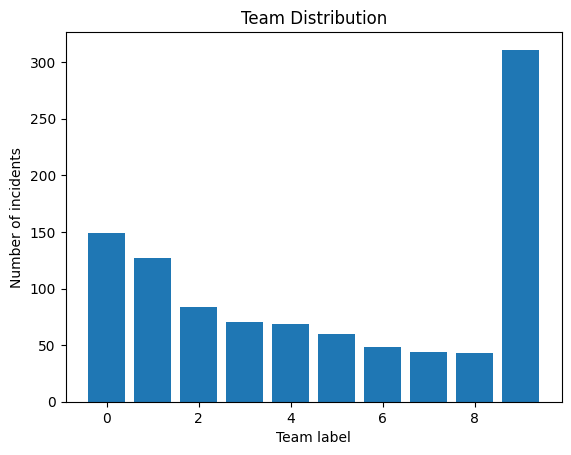

In [ ]:
# Plot the graph
plt.bar(team_number_counts["team_number"], team_number_counts["count"])

# Set labels and title
plt.xlabel("Team label")
plt.ylabel("Number of incidents")
plt.title("Team Distribution")

# Show the plot
plt.show()

## Train & Test sets

In [ ]:
test_ratio = 0.2
train_ind, test_ind = train_test_split(
    incidents.index, test_size=test_ratio, shuffle=True, random_state=random_state)

train_df = incidents.loc[train_ind, :]
test_df = incidents.loc[test_ind, :]

In [ ]:
print(incidents.shape)
print(train_df.shape)
print(test_df.shape)

(1005, 10)
(804, 10)
(201, 10)


## Balance the labels of the training set

In [ ]:
min_train_count = train_df["team_number"].value_counts().min()
min_train_count

36

In [ ]:
train_df = pd.concat([group.sample(min_train_count)
                     for name, group in train_df.groupby("team_number")])

In [ ]:
train_team_counts = train_df["team_number"].value_counts().reset_index()
train_team_counts.columns = ["team_number", "count"]

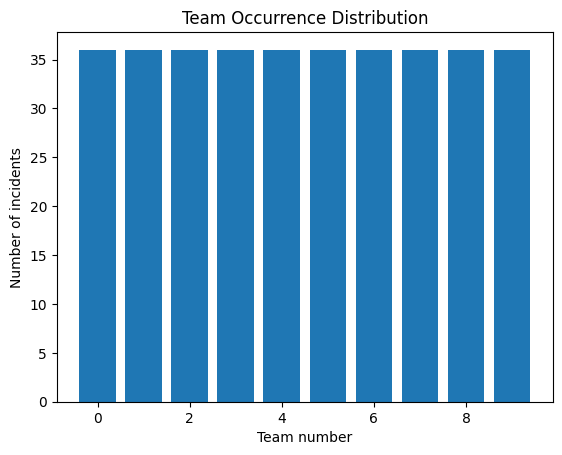

In [ ]:
# Plot the graph
plt.bar(train_team_counts["team_number"], train_team_counts["count"])

# Set labels and title
plt.xlabel("Team number")
plt.ylabel("Number of incidents")
plt.title("Team Occurrence Distribution")

# Show the plot
plt.show()

## Get the text and the labels

In [ ]:
text = train_df["description"].values
labels = train_df["team_number"].values

In [ ]:
print(text.shape)
print(labels.shape)

(360,)
(360,)


## Tokenize

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(train_team_counts), output_attentions=False, output_hidden_states=True)

#### Get the token_ids and attention_masks

In [ ]:
token_ids = []
attention_masks = []
for description in text:
    encoding_dict = tokenizer.encode_plus(description, add_special_tokens=True, max_length=256,
                                          pad_to_max_length=True, return_attention_mask=True, return_tensors="pt")
    token_ids.append(encoding_dict["input_ids"])
    attention_masks.append(encoding_dict["attention_mask"])

#### Get in torch tensors

In [ ]:
token_ids = torch.cat(token_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

## Train & Validation sets

In [ ]:
# Parameters
val_ratio = 0.2
batch_size = 16

# Indices of the train and validation splits stratified by labels
train_ind, val_ind = train_test_split(np.arange(len(
    labels)), test_size=val_ratio, shuffle=True, stratify=labels, random_state=random_state)

# Prepare TensorsDataset
train_set = TensorDataset(
    token_ids[train_ind], attention_masks[train_ind], labels[train_ind])
val_set = TensorDataset(
    token_ids[val_ind], attention_masks[val_ind], labels[val_ind])

# Prepare DataLoader
train_dataloader = DataLoader(
    train_set, sampler=RandomSampler(train_set), batch_size=batch_size)
val_dataloader = DataLoader(
    val_set, sampler=SequentialSampler(val_set), batch_size=batch_size)

## Training

## Validation metrics

In [ ]:
def f1_score_func(predictions, labels):
    preds_flat = np.argmax(predictions, axis=1).flatten()
    labels_flat = labels.flatten()
    return f1_score(labels_flat, preds_flat, average="weighted")

In [ ]:
label_dict = pd.Series(
    incidents["team_number"].values, index=incidents["team"]).to_dict()

In [ ]:
def accuracy_per_class(predictions, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}

    predictions_flat = np.argmax(predictions, axis=1).flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_predictions = predictions_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        print(f"Class: {label_dict_inverse[label]}")
        print(
            f"Accuracy: {len(y_predictions[y_predictions == label])}/{len(y_true)}\n")

#### Training Setup

In [ ]:
epochs = 5
optimizer = AdamW(model.parameters(), lr=1e-5, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=len(train_dataloader)*epochs)

In [ ]:
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

#### Training

In [ ]:
def evaluate(val_dataloader):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in val_dataloader:

        batch = tuple(b.to(device) for b in batch)

        inputs = {"input_ids":      batch[0],
                  "attention_mask": batch[1],
                  "labels":         batch[2],
                  }

        with torch.no_grad():
            outputs = model(**inputs)

        loss = outputs[0]
        logits = outputs[1]
        loss_val_total += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = inputs["labels"].cpu().numpy()
        predictions.append(logits)
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(val_dataloader)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [ ]:
for epoch in tqdm(range(1, epochs+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(train_dataloader, desc="Epoch {:1d}".format(
        epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

        inputs = {"input_ids":      batch[0],
                  "attention_mask": batch[1],
                  "labels":         batch[2],
                  }

        outputs = model(**inputs)

        loss = outputs[0]
        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix(
            {"training_loss": "{:.3f}".format(loss.item()/len(batch))})

    torch.save(model.state_dict(),
               f"/content/finetuned_BERT_epoch_{epoch}.model")

    tqdm.write(f"\nEpoch {epoch}")

    loss_train_avg = loss_train_total/len(train_dataloader)
    tqdm.write(f"Training loss: {loss_train_avg}")

    val_loss, predictions, true_vals = evaluate(val_dataloader)
    val_f1 = f1_score_func(predictions, true_vals)
    tqdm.write(f"Validation loss: {val_loss}")
    tqdm.write(f"F1 Score (Weighted): {val_f1}")

## Predict

#### Prepare the data

In [ ]:
test_text = test_df["description"].values
test_labels = test_df["team_number"].values

In [ ]:
test_token_ids = []
test_attention_masks = []
for test_description in test_text:
    test_encoding_dict = tokenizer.encode_plus(test_description, add_special_tokens=True,
                                               max_length=256, pad_to_max_length=True, return_attention_mask=True, return_tensors="pt")
    test_token_ids.append(test_encoding_dict["input_ids"])
    test_attention_masks.append(test_encoding_dict["attention_mask"])

In [ ]:
test_token_ids = torch.cat(test_token_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)
test_labels = torch.tensor(test_labels)

In [ ]:
test_set = TensorDataset(test_token_ids, test_attention_masks, test_labels)
test_dataloader = DataLoader(
    test_set, sampler=RandomSampler(test_set), batch_size=batch_size)

#### Evaluate the test samples

In [ ]:
_, test_predictions, test_true_vals = evaluate(test_dataloader)

#### Scores

In [ ]:
test_f1_weighted = f1_score_func(test_predictions, test_true_vals)
print(f"F1 Score (Weighted): {test_f1_weighted}")

In [ ]:
accuracy_per_class(test_predictions, test_true_vals)

#### Get the embeddings

In [ ]:
description_sample = "Hello Antoine ! How are you doing ?"
team_sample = "team_aa"

In [ ]:
sample_encoding_dict = tokenizer.encode_plus(description_sample, add_special_tokens=True,
                                             max_length=256, pad_to_max_length=True, return_attention_mask=True, return_tensors="pt")
sample_token_ids = sample_encoding_dict["input_ids"]
sample_attention_mask = sample_encoding_dict["attention_mask"]

In [ ]:
output = model(sample_token_ids, sample_attention_mask)
hidden_state = output.hidden_states[-1]
sample_embedding = torch.mean(hidden_state, dim=1)

In [ ]:
print(sample_embedding)